<a href="https://colab.research.google.com/github/abhinav-sharma15/marketing-measurement-system/blob/main/notebooks/01_geo_lift_did_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

In [3]:
n_geos = 24
n_weeks = 12

geos = [f"Geo_{i+1}" for i in range(n_geos)]
weeks = np.arange(1, n_weeks + 1)

df = pd.MultiIndex.from_product(
    [geos, weeks],
    names=["geo", "week"]
).to_frame(index=False)

df.head()

,geo,week
0,Geo_1,1
1,Geo_1,2
2,Geo_1,3
3,Geo_1,4
4,Geo_1,5


In [4]:
treated_geos = np.random.choice(geos, size=n_geos // 2, replace=False)

df["treatment"] = df["geo"].isin(treated_geos).astype(int)
df["post_period"] = (df["week"] >= 7).astype(int)

df.head()

,geo,week,treatment,post_period
0,Geo_1,1,1,0
1,Geo_1,2,1,0
2,Geo_1,3,1,0
3,Geo_1,4,1,0
4,Geo_1,5,1,0


In [5]:
geo_baseline = {
    geo: np.random.normal(1000, 150)
    for geo in geos
}

df["geo_baseline"] = df["geo"].map(geo_baseline)

df["time_trend"] = df["week"] * 20

df["seasonality"] = 80 * np.sin(2 * np.pi * df["week"] / 12)

df["noise"] = np.random.normal(0, 80, size=len(df))

In [6]:
true_treatment_effect = 180

df["treatment_effect"] = (
    df["treatment"] *
    df["post_period"] *
    true_treatment_effect
)

In [7]:
df["revenue"] = (
    df["geo_baseline"]
    + df["time_trend"]
    + df["seasonality"]
    + df["treatment_effect"]
    + df["noise"]
)

df.head()

,geo,week,treatment,post_period,geo_baseline,time_trend,seasonality,noise,treatment_effect,revenue
0,Geo_1,1,1,0,1036.294341,20,40.000000,16.709088,0,1113.003428
1,Geo_1,2,1,0,1036.294341,40,69.282032,-156.773610,0,988.802763
2,Geo_1,3,1,0,1036.294341,60,80.000000,-106.254884,0,1070.039457
3,Geo_1,4,1,0,1036.294341,80,69.282032,15.748899,0,1201.325272
4,Geo_1,5,1,0,1036.294341,100,40.000000,59.077326,0,1235.371667


In [8]:
df.groupby("treatment")["geo"].nunique()

,geo
treatment,
0,12
1,12


In [9]:
df.groupby(["treatment", "post_period"])["revenue"].mean()

treatment  post_period
0          0              1084.772065
           1              1105.949743
1          0              1032.160138
           1              1254.718152
Name: revenue, dtype: float64

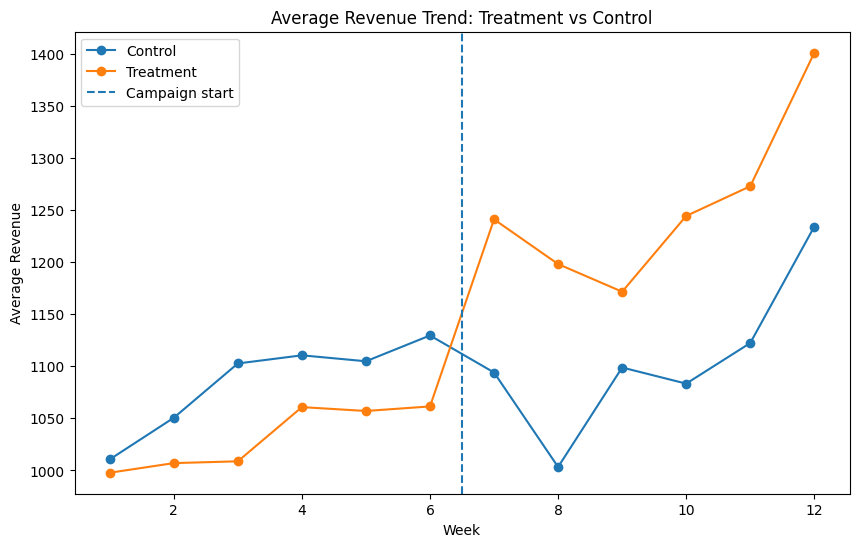

In [10]:
trend = (
    df.groupby(["week", "treatment"])["revenue"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(10, 6))

for treatment_value, label in [(0, "Control"), (1, "Treatment")]:
    subset = trend[trend["treatment"] == treatment_value]
    plt.plot(subset["week"], subset["revenue"], marker="o", label=label)

plt.axvline(6.5, linestyle="--", label="Campaign start")
plt.title("Average Revenue Trend: Treatment vs Control")
plt.xlabel("Week")
plt.ylabel("Average Revenue")
plt.legend()
plt.show()

## Interpretation

This synthetic dataset represents a geo lift experiment.

- 24 geographies are observed over 12 weeks
- Half are assigned to treatment
- Treatment starts in week 7
- Revenue is affected by:
  - geo-level baseline demand
  - common time trend
  - seasonality
  - random noise
  - treatment effect

The goal is to estimate whether treated geos experienced additional growth after week 7 compared with control geos.

In [11]:
df["did_interaction"] = df["treatment"] * df["post_period"]

df[["geo", "week", "treatment", "post_period", "did_interaction", "revenue"]].head(10)

,geo,week,treatment,post_period,did_interaction,revenue
0,Geo_1,1,1,0,0,1113.003428
1,Geo_1,2,1,0,0,988.802763
2,Geo_1,3,1,0,0,1070.039457
3,Geo_1,4,1,0,0,1201.325272
4,Geo_1,5,1,0,0,1235.371667
5,Geo_1,6,1,0,0,1170.003803
6,Geo_1,7,1,1,1,1307.042478
7,Geo_1,8,1,1,1,1282.924013
8,Geo_1,9,1,1,1,1198.012582
9,Geo_1,10,1,1,1,1289.424772


In [12]:
did_table = (
    df.groupby(["treatment", "post_period"])["revenue"]
    .mean()
    .reset_index()
)

did_table

,treatment,post_period,revenue
0,0,0,1084.772065
1,0,1,1105.949743
2,1,0,1032.160138
3,1,1,1254.718152


In [13]:
did_pivot = did_table.pivot(
    index="treatment",
    columns="post_period",
    values="revenue"
)

did_pivot.columns = ["pre_period", "post_period"]
did_pivot.index = ["control", "treatment"]

did_pivot

,pre_period,post_period
control,1084.772065,1105.949743
treatment,1032.160138,1254.718152


In [14]:
control_change = did_pivot.loc["control", "post_period"] - did_pivot.loc["control", "pre_period"]
treatment_change = did_pivot.loc["treatment", "post_period"] - did_pivot.loc["treatment", "pre_period"]

manual_did = treatment_change - control_change

print(f"Control change: {control_change:.2f}")
print(f"Treatment change: {treatment_change:.2f}")
print(f"Manual DiD estimate: {manual_did:.2f}")

Control change: 21.18
Treatment change: 222.56
Manual DiD estimate: 201.38


The manual DiD estimate represents the additional post-period revenue growth in treatment geos compared with control geos.

Because the true simulated treatment effect was set to 180, the estimated DiD value should be reasonably close to 180, with some deviation due to noise.

In [15]:
import statsmodels.formula.api as smf

In [16]:
did_model = smf.ols(
    "revenue ~ treatment + post_period + did_interaction",
    data=df
).fit()

print(did_model.summary())

                            OLS Regression Results                            
Dep. Variable:                revenue   R-squared:                       0.208
Model:                            OLS   Adj. R-squared:                  0.200
Method:                 Least Squares   F-statistic:                     24.93
Date:                Mon, 01 Jun 2026   Prob (F-statistic):           2.39e-14
Time:                        13:27:27   Log-Likelihood:                -1872.1
No. Observations:                 288   AIC:                             3752.
Df Residuals:                     284   BIC:                             3767.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept        1084.7721     19.107     

In [17]:
did_effect = did_model.params["did_interaction"]
did_pvalue = did_model.pvalues["did_interaction"]

print(f"Estimated DiD effect: {did_effect:.2f}")
print(f"P-value: {did_pvalue:.4f}")

Estimated DiD effect: 201.38
P-value: 0.0000


## Regression Interpretation

The DiD regression estimates the following relationship:

revenue = baseline + treatment_group_difference + post_period_change + treatment_post_effect

The key coefficient is `did_interaction`.

This coefficient estimates how much more revenue changed in treatment geos after the campaign compared with control geos.

If the coefficient is positive and statistically meaningful, it suggests the campaign generated incremental lift.

In [19]:
treatment_pre_mean = did_pivot.loc["treatment", "pre_period"]

lift_pct = did_effect / treatment_pre_mean

print(f"Treatment pre-period average revenue: {treatment_pre_mean:.2f}")
print(f"Incremental lift (%): {lift_pct:.2%}")

Treatment pre-period average revenue: 1032.16
Incremental lift (%): 19.51%


## Lift Interpretation

The estimated lift percentage compares the incremental revenue effect against the treatment group's pre-period baseline.

This helps translate the regression coefficient into a more business-friendly metric.

For example, if the estimated effect is 180 and the pre-period average revenue is 1,100, then the campaign produced roughly 16% incremental lift.

In [20]:
conf_int = did_model.conf_int().loc["did_interaction"]

print(f"95% confidence interval: [{conf_int[0]:.2f}, {conf_int[1]:.2f}]")

95% confidence interval: [126.16, 276.60]


## Confidence Interval

The confidence interval gives a plausible range for the incremental effect.

A narrow interval means the estimate is more precise.

A wide interval means there is more uncertainty, often due to:
- small sample size
- high noise
- weak treatment/control comparability

In [21]:
trend = (
    df.groupby(["week", "treatment"])["revenue"]
    .mean()
    .reset_index()
)

control_trend = trend[trend["treatment"] == 0].copy()
treatment_trend = trend[trend["treatment"] == 1].copy()

In [22]:
pre_treatment_gap = (
    treatment_trend[treatment_trend["week"] < 7]["revenue"].mean()
    - control_trend[control_trend["week"] < 7]["revenue"].mean()
)

treatment_counterfactual = control_trend.copy()
treatment_counterfactual["revenue"] = treatment_counterfactual["revenue"] + pre_treatment_gap

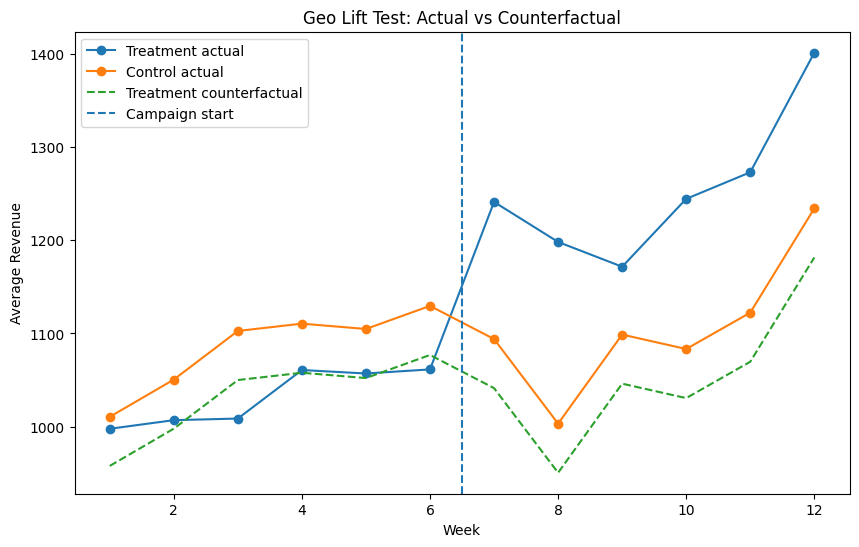

In [23]:
plt.figure(figsize=(10, 6))

plt.plot(
    treatment_trend["week"],
    treatment_trend["revenue"],
    marker="o",
    label="Treatment actual"
)

plt.plot(
    control_trend["week"],
    control_trend["revenue"],
    marker="o",
    label="Control actual"
)

plt.plot(
    treatment_counterfactual["week"],
    treatment_counterfactual["revenue"],
    linestyle="--",
    label="Treatment counterfactual"
)

plt.axvline(6.5, linestyle="--", label="Campaign start")

plt.title("Geo Lift Test: Actual vs Counterfactual")
plt.xlabel("Week")
plt.ylabel("Average Revenue")
plt.legend()
plt.show()

## Counterfactual Interpretation

The dashed counterfactual line estimates how treatment geos may have performed without the campaign.

The gap between:
- treatment actual
- treatment counterfactual

after campaign launch represents estimated incremental lift.

# Business Readout

## Question

Did the campaign generate incremental revenue in treatment geos?

## Method

We used a Difference-in-Differences design comparing:
- treatment geos where the campaign was active
- control geos where the campaign was not active

before and after campaign launch.

## Result

The estimated incremental revenue lift was approximately:

[insert DiD estimate]

This corresponds to approximately:

[insert lift percentage]

relative to the treatment group baseline.

## Interpretation

The campaign appears to have generated incremental revenue beyond the growth observed in control geos.

## Assumptions

This interpretation relies on:
- treatment and control geos having similar pre-period trends
- no major spillovers across regions
- no external shocks affecting only one group
- stable campaign execution during the test

## Recommendation

If the estimate is positive and credible, the campaign should be considered for scaling.

However, before scaling, we should:
- validate pre-period trends
- check robustness
- run sensitivity tests
- monitor whether lift persists over time

In [24]:
summary = pd.DataFrame({
    "metric": [
        "Control pre/post change",
        "Treatment pre/post change",
        "Estimated incremental lift",
        "Estimated lift %",
        "P-value"
    ],
    "value": [
        control_change,
        treatment_change,
        did_effect,
        lift_pct,
        did_pvalue
    ]
})

summary

,metric,value
0,Control pre/post change,2.117768e+01
1,Treatment pre/post change,2.225580e+02
2,Estimated incremental lift,2.013803e+02
3,Estimated lift %,1.951057e-01
4,P-value,2.703791e-07
